# **libraries**

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from category_encoders import OneHotEncoder , OrdinalEncoder

import warnings 
warnings.filterwarnings('ignore')

In [2]:
from preprocessing import read_data , check_types , check_nulls

# **Read_Data**

In [3]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#from function
from preprocessing import read_data 
df = read_data('insurance.csv')

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# **Data_Types**

In [7]:
df.nunique()   

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [8]:
dtypes = df.dtypes
dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [9]:
#merge in a table
dtypes = df.dtypes
n_unique = df.nunique()
pd.DataFrame({"A":dtypes, "B":n_unique}).T

,age,sex,bmi,children,smoker,region,charges
A,int64,object,float64,int64,object,object,float64
B,47,2,548,6,2,4,1337


In [10]:
#in a function
def check_types(df):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    return pd.DataFrame({'Dtypes': dtypes, 'Num_unique' : n_uniq}).T

check_types(df)

,age,sex,bmi,children,smoker,region,charges
Dtypes,int64,object,float64,int64,object,object,float64
Num_unique,47,2,548,6,2,4,1337


In [11]:
#from a function 
from preprocessing import check_types
check_types(df)

,age,sex,bmi,children,smoker,region,charges
Dtypes,int64,object,float64,int64,object,object,float64
Num_unique,47,2,548,6,2,4,1337


In [12]:
cat_col = ['sex', 'children', 'smoker', 'region']
df[cat_col] = df[cat_col].astype('category')
check_types(df)

,age,sex,bmi,children,smoker,region,charges
Dtypes,int64,category,float64,category,category,category,float64
Num_unique,47,2,548,6,2,4,1337


# **Check_nulls**

In [13]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
#rows numbers
df.shape[0]

1338

In [15]:
#cols numbers
df.shape[1]

7

In [16]:
ratio = (df.isnull().sum() / df.shape[0])*100 
ratio

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [17]:
def check_nulls(df):
    null = df.isnull().sum()
    #ratio = (null/df.shape[0])*100 
    ratio = round((null/df.shape[0])*100,2).astype(str)+'%'

    return pd.DataFrame({'Null_Sum': null, 'Ratio': ratio}).T

check_nulls(df)


,age,sex,bmi,children,smoker,region,charges
Null_Sum,0,0,0,0,0,0,0
Ratio,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


In [18]:
#from a function
from preprocessing import check_nulls
check_nulls(df)

,age,sex,bmi,children,smoker,region,charges
Null_Sum,0,0,0,0,0,0,0
Ratio,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


**if small number of Nulls --> drop them --> dropna()**

**if not <30% --> replace them by mean or mode or median( if we have outliers )-->fillna()**

**if huge --> drop col --> drop()**

**numerical --> median/mean , categorical -->mode**

# **Check_duplicates**

In [19]:
df.duplicated().sum()

np.int64(1)

In [20]:
#df.drop_duplicates(inplace=True)

In [21]:
def check_duplicated(df):
    print("Before removing duplicated rows:")
    print(f"Duplicated rows count: {df.duplicated().sum()}")
    print(f"Total rows: {(df.shape[0])}")

    df.drop_duplicates(inplace=True)

    print("\nAfter removing duplicated rows:")
    print(f"Duplicated rows count: {df.duplicated().sum()}")
    print(f"Total rows: {(df.shape[0])}")
    
    return df

check_duplicated(df)


Before removing duplicated rows:
Duplicated rows count: 1
Total rows: 1338

After removing duplicated rows:
Duplicated rows count: 0
Total rows: 1337


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [22]:
from preprocessing import check_duplicated
check_duplicated(df)

Before removing duplicated rows:
Duplicated rows count: 0
Total rows: 1337

After removing duplicated rows:
Duplicated rows count: 0
Total rows: 1337


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **check_outliers**

In [23]:
num_cols = df.select_dtypes('number').columns
print("Numerical columns:",num_cols.tolist())

Numerical columns: ['age', 'bmi', 'charges']


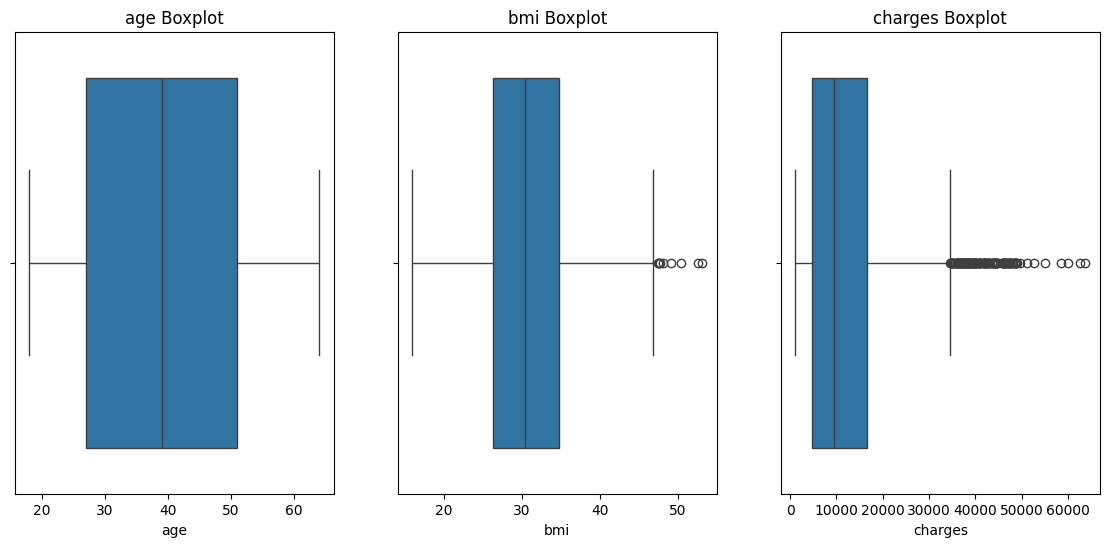

In [24]:
plt.figure(figsize = (14,6))
for i , col in enumerate(num_cols):
    plt.subplot(1,len(num_cols),i+1)
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col} Boxplot')
plt.show()

In [25]:
Q1 = df.bmi.quantile(.25)
Q3 = df.bmi.quantile(.75)
IQR = Q3 -Q1
upper = Q3 + 1.5*IQR
outliers = df[df.bmi  > upper].bmi.values
df.bmi.replace(outliers, upper,inplace=True)

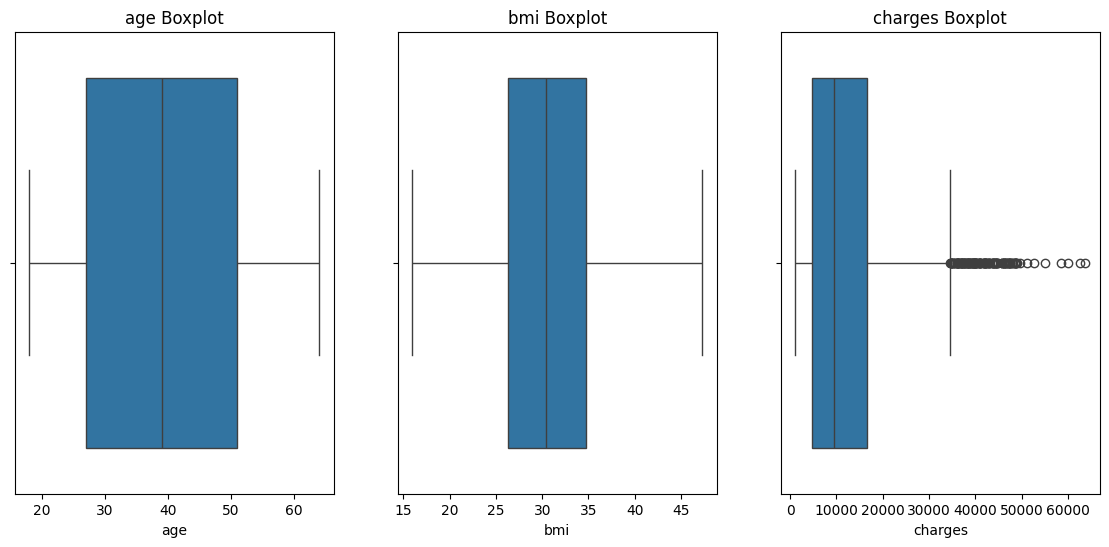

In [26]:
plt.figure(figsize = (14,6))
for i , col in enumerate(num_cols):
    plt.subplot(1,len(num_cols),i+1)
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col} Boxplot')
plt.show()

In [27]:
from preprocessing import check_outliers
check_outliers(df)

Numerical columns: ['age', 'bmi', 'charges']
Plotting before handling outliers...
Plotting after handling outliers...


# **visualization**

In [28]:
num_col = ['age', 'bmi']
cat_col = ['sex','children','smoker','region']

**if 2 numerical cols --> scatter, pair, line, heatmap plts**

**if one numercial & one categorical --> barplot**

**if 2 categorical cols --> heatmap**

**scatterplot**

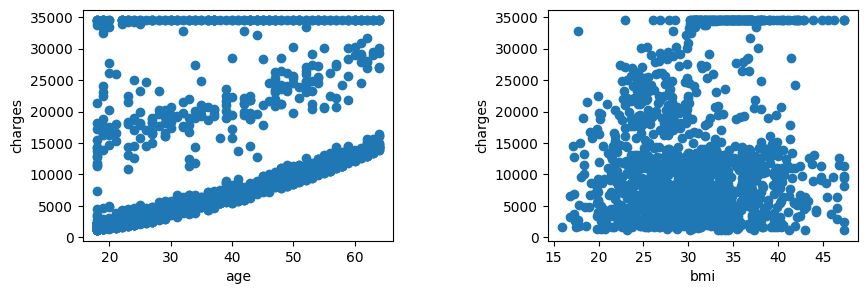

In [29]:
plt.figure(figsize=(10,3))
for i , col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    plt.xlabel(f'{col}')
    plt.ylabel(f'charges')
    plt.scatter(df[col],df['charges'])
plt.subplots_adjust(hspace=1.5, wspace=0.5)
plt.show()
    

**barplot**

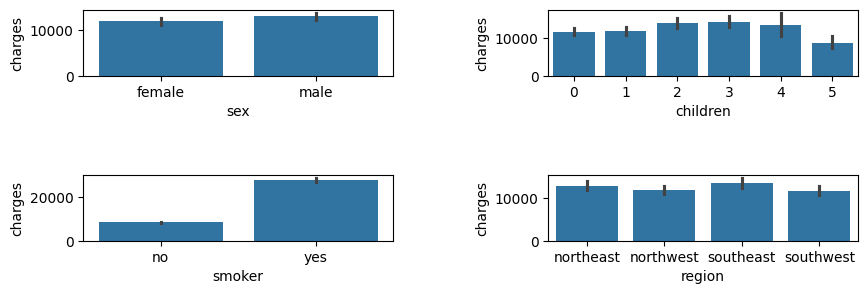

In [30]:
plt.figure(figsize=(10,3))
for i , col in enumerate(cat_col):
    plt.subplot(2,2,i+1)
    plt.xlabel(f'{col}')
    plt.ylabel(f'charges')
    sns.barplot(x=col,y='charges', data= df)
plt.subplots_adjust(hspace=1.5, wspace=0.5)
plt.show()
    

**HeatMap**

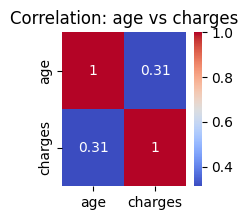

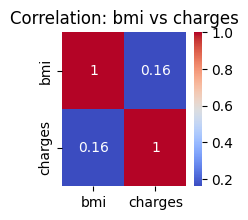

In [31]:
for col in num_col:
    corr = df[[col, 'charges']].corr()
    plt.figure(figsize=(2,2))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title(f"Correlation: {col} vs charges")
    plt.show()

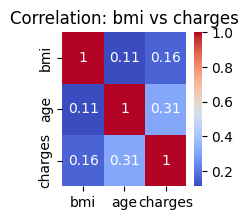

In [32]:
corr = df[['bmi','age', 'charges']].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title(f"Correlation: {col} vs charges")
plt.show()

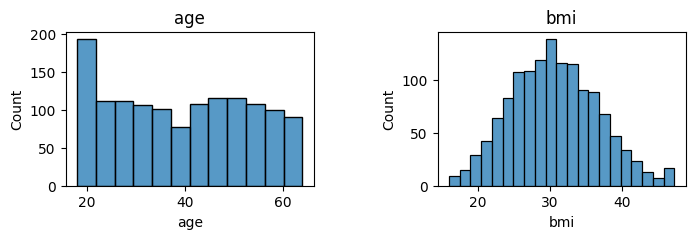

In [33]:
plt.figure(figsize=(8, 2))
for i, col in enumerate(num_col):
    plt.subplot(1, 2, i+1)
    plt.title(f"{col}")
    sns.histplot(x=col, data=df)
plt.subplots_adjust(hspace=.5, wspace=.5)
plt.show()

# **splitting data**

In [34]:
y = df['charges']
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [35]:
x = df.iloc[:,:-1]
x.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


# **Normalization**

scale the data in range [0:1]


In [36]:
col_num_norm = x.select_dtypes('number').columns
col_num_norm

Index(['age', 'bmi'], dtype='object')

In [37]:
scaler = MinMaxScaler()

In [38]:
x[col_num_norm] = scaler.fit_transform(x[col_num_norm])
x.head()

,age,sex,bmi,children,smoker,region
0,0.021739,female,0.380801,0,yes,southwest
1,0.000000,male,0.568011,1,no,southeast
2,0.217391,male,0.543454,3,no,southeast
3,0.326087,male,0.215117,0,no,northwest
4,0.304348,male,0.412055,0,no,northwest


# **Encoding**

In [39]:
x.select_dtypes('category').columns

Index(['sex', 'children', 'smoker', 'region'], dtype='object')

In [40]:
check_types(x)

,age,sex,bmi,children,smoker,region
Dtypes,float64,category,float64,category,category,category
Num_unique,47,2,540,6,2,4


In [41]:
encoder = OneHotEncoder(cols = ['sex','smoker'], drop_invariant=True)
x = encoder.fit_transform(x)
x.head()

,age,sex_1,sex_2,bmi,children,smoker_1,smoker_2,region
0,0.021739,1,0,0.380801,0,1,0,southwest
1,0.000000,0,1,0.568011,1,0,1,southeast
2,0.217391,0,1,0.543454,3,0,1,southeast
3,0.326087,0,1,0.215117,0,0,1,northwest
4,0.304348,0,1,0.412055,0,0,1,northwest


In [ ]:
cols_to_encoder = ['children','region']
ordinal_encoder = OrdinalEncoder(cols=cols_to_encoder)
x = ordinal_encoder.fit_transform(x)
x.head()

#Target for region افضل نعمله بعدين 

,age,sex_1,sex_2,bmi,children,smoker_1,smoker_2,region
0,0.021739,1,0,0.380801,1,1,0,1
1,0.000000,0,1,0.568011,2,0,1,2
2,0.217391,0,1,0.543454,3,0,1,2
3,0.326087,0,1,0.215117,1,0,1,3
4,0.304348,0,1,0.412055,1,0,1,3
